# 12 — Hyperparameter × τ surfaces + routing grid revisited (WP4)

Two sensitivity questions on the **full 56-feature set**:
1. How sensitive are the single detectors to their main hyperparameter, jointly with the
   percentile threshold τ? (OC-SVM ν and IF contamination × the τ grid; **AE excluded** —
   cost + nondeterminism; the production combos reuse the WP1 cached fold scores.)
2. Does the (usd, oro) routing-threshold choice survive alternative optimization objectives?
   (`optimize_routing_thresholds` generalized with an `objective` parameter that **defaults to
   the original duration-weighted-median-Calmar behavior**.)

Metrics are n_pos-weighted across the 5 walk-forward folds; no holdout contact.

In [1]:
import os, sys, time
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')  # handoff par.5.3: deterministic AE
os.environ.setdefault('TF_DETERMINISTIC_OPS', '1')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.sensitivity import (cache_fold_scores, hyperparam_tau_surface,
                             plot_hyperparam_tau_surface, routing_inputs,
                             PRODUCTION_TAU, FIGURES_DIR, TABLES_DIR)
from src.routing import optimize_routing_thresholds
fs = cache_fold_scores()  # WP1 cache (hit)

## OC-SVM ν × τ surface (γ fixed at the production 0.001)

svm nu=0.05: refit 5 folds
svm nu=0.15: refit 5 folds
svm nu=0.22: refit 5 folds


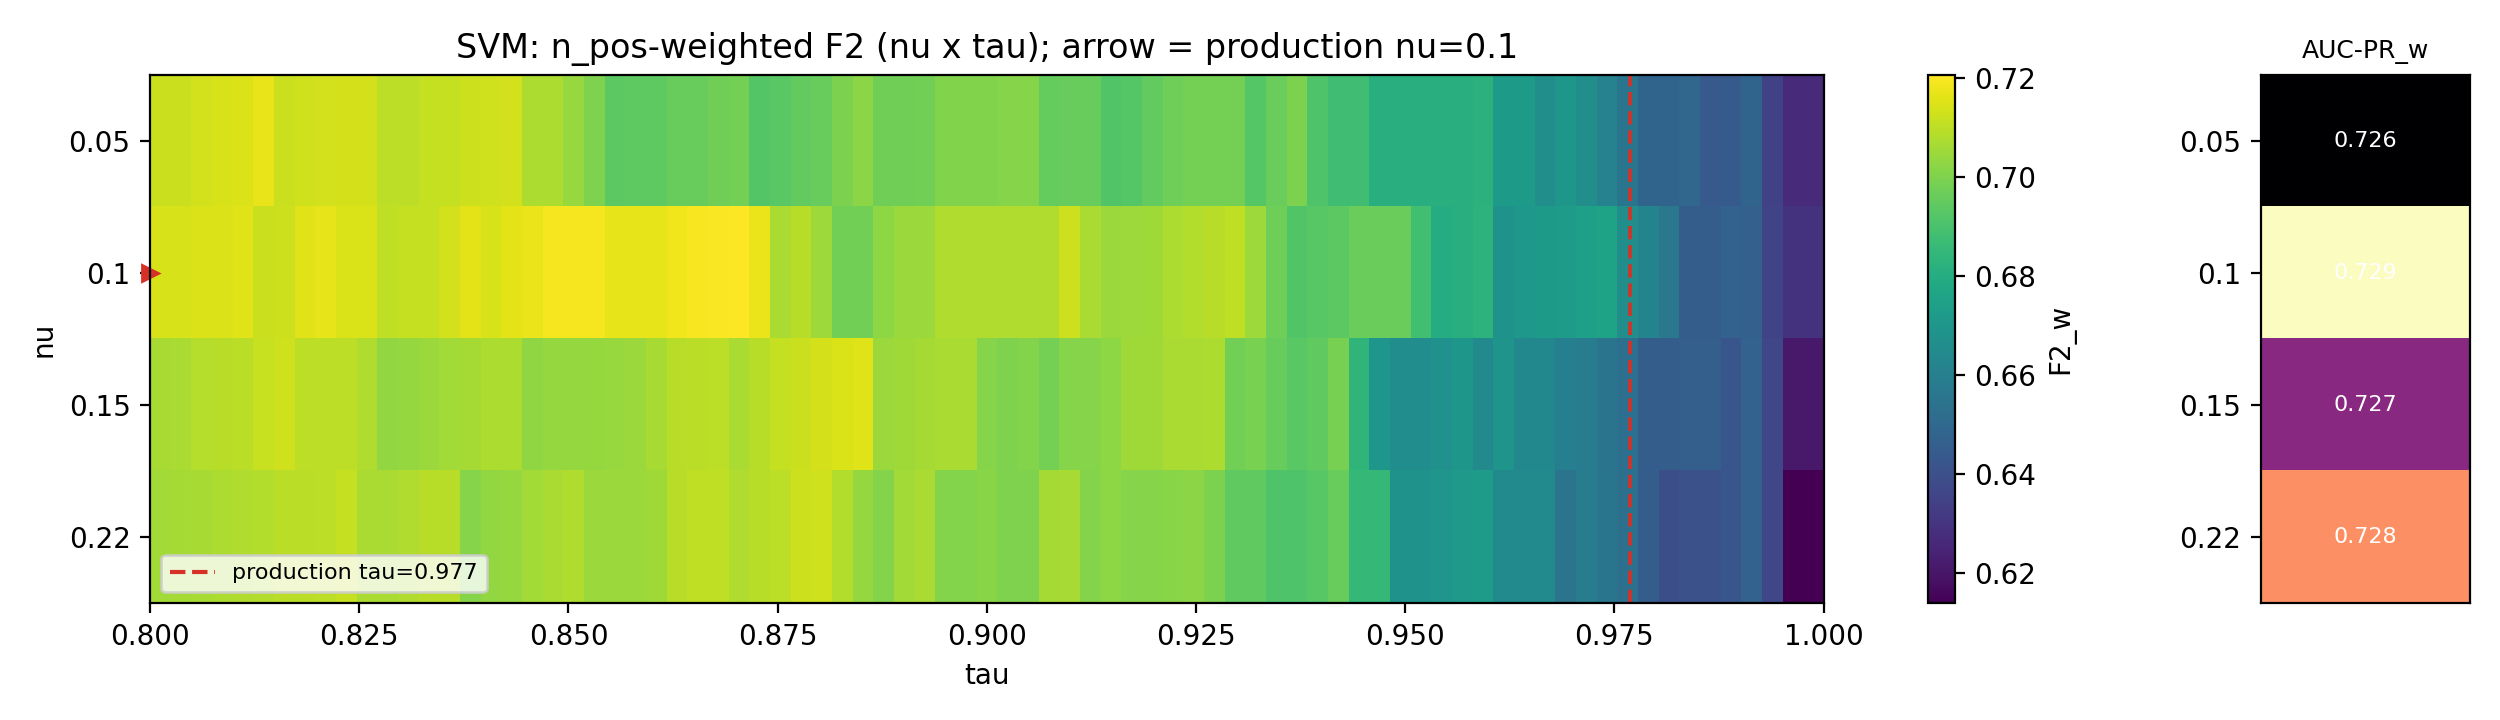

In [2]:
svm_surf = hyperparam_tau_surface('svm', fold_scores=fs)  # -> svm_nu_tau_surface.csv
from IPython.display import Image
Image(filename=str(plot_hyperparam_tau_surface(svm_surf, 'svm')), width=950)

In [3]:
svm_best = svm_surf.loc[svm_surf.groupby('hyperparam')['F2_w'].idxmax()]
print('per-nu best F2_w (and where):')
display(svm_best[['hyperparam', 'tau', 'F2_w', 'AUC_PR_w']].round(4))

per-nu best F2_w (and where):


,hyperparam,tau,F2_w,AUC_PR_w
5,0.05,0.8125,0.7171,0.7259
109,0.10,0.8700,0.7208,0.7290
196,0.15,0.8850,0.7157,0.7271
275,0.22,0.8800,0.7131,0.7283


## IF contamination × τ surface
`score_samples` is contamination-invariant with fixed `random_state` (handoff §1.9.4):
contamination only moves the operating point, never the scores. The function asserts this by
refitting fold 1 at contamination=0.05 and comparing to the cached scores — so the 4 rows of
this surface are **identical by construction**, which is itself the sensitivity finding.

IF invariance asserted: contamination=0.05 scores == cached (max abs diff 0.00e+00)


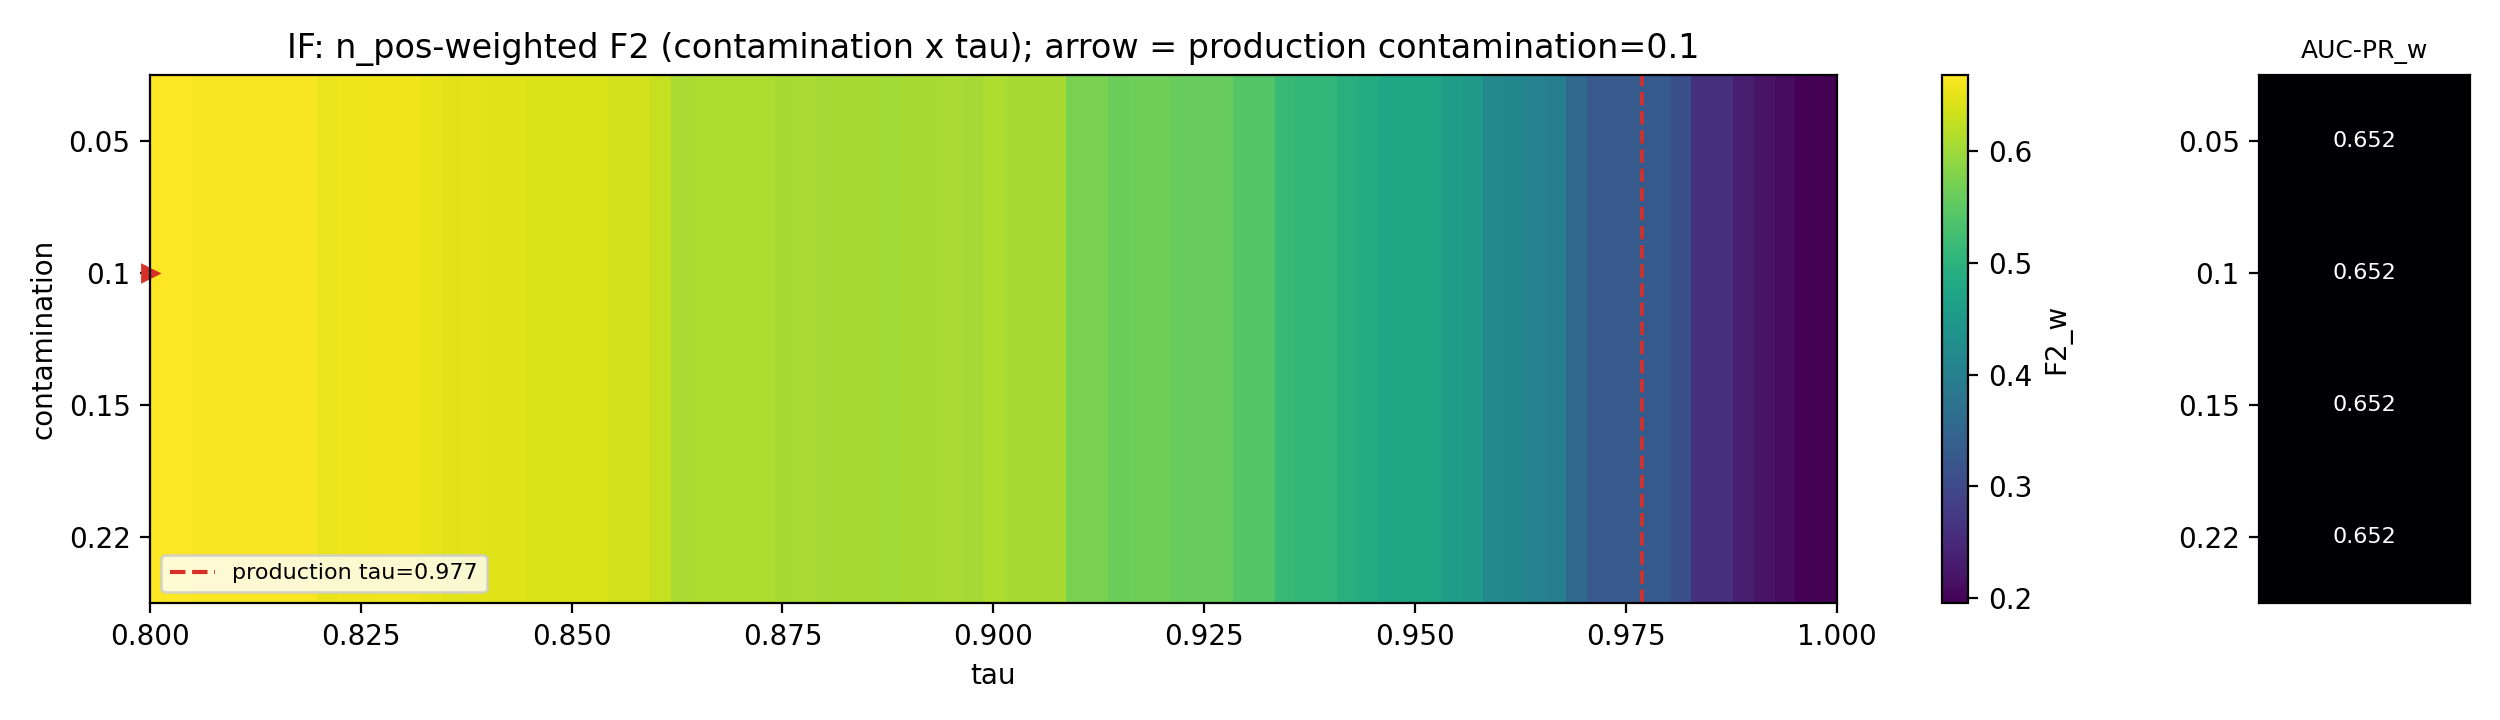

In [4]:
if_surf = hyperparam_tau_surface('if', fold_scores=fs)  # -> if_contamination_tau_surface.csv
Image(filename=str(plot_hyperparam_tau_surface(if_surf, 'if')), width=950)

## Routing grid revisited — 4 objectives
Ensemble flags per fold come from the WP1 cached scores at the production τ; sub-scores and
routing fold-vals are the committed artifacts. `objective='calmar_wmedian'` is the original
behavior (default).

In [5]:
inp = routing_inputs(fold_scores=fs)
for fid, s in inp['ensemble_per_fold'].items():
    print(f"fold {fid}: {int(s.sum())} risk-off weeks of {len(s)}")
OBJECTIVES = ['calmar_wmedian', 'sortino_wmedian', 'cost_C', 'calmar_concat']
results = {}
for obj in OBJECTIVES:
    best, grid = optimize_routing_thresholds(
        inp['folds_routing'], inp['ensemble_per_fold'], inp['subscores_per_fold'],
        inp['prices'], inp['tc'], objective=obj, y_per_fold=inp['y_per_fold'])
    results[obj] = {'best': best, 'grid': grid}
    print(f"{obj:<16} best (usd, oro) = ({best['usd']}, {best['oro']})")

fold 1: 78 risk-off weeks of 153
fold 2: 87 risk-off weeks of 152
fold 3: 4 risk-off weeks of 101
fold 4: 10 risk-off weeks of 100
fold 5: 2 risk-off weeks of 100


calmar_wmedian   best (usd, oro) = (1.5, 0.5)


sortino_wmedian  best (usd, oro) = (1.5, 0.5)


cost_C           best (usd, oro) = (0.5, 0.5)


calmar_concat    best (usd, oro) = (1.5, 0.5)


In [6]:
# one heatmap per objective (dpi=200) + the production choice (1.5, 0.5) outlined
for obj in OBJECTIVES:
    grid = results[obj]['grid']; best = results[obj]['best']
    piv = grid.pivot(index='oro', columns='usd', values=obj)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(piv.to_numpy(), cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(piv.columns)), [str(c) for c in piv.columns])
    ax.set_yticks(range(len(piv.index)), [str(i) for i in piv.index])
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f'{piv.iloc[i, j]:.3f}', ha='center', va='center',
                    color='white', fontsize=8)
    bi, bj = list(piv.index).index(best['oro']), list(piv.columns).index(best['usd'])
    ax.add_patch(plt.Rectangle((bj-0.5, bi-0.5), 1, 1, fill=False, edgecolor='red', lw=2.5))
    pi, pj = list(piv.index).index(0.5), list(piv.columns).index(1.5)
    ax.add_patch(plt.Rectangle((pj-0.5, pi-0.5), 1, 1, fill=False, edgecolor='white',
                               lw=2, ls='--'))
    ax.set_xlabel('usd threshold'); ax.set_ylabel('oro threshold')
    ax.set_title(f'{obj} (red = argbest, dashed white = production (1.5, 0.5))')
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'routing_grid_{obj}.png', dpi=200)
    plt.show()

In [7]:
rows = []
for obj in OBJECTIVES:
    grid = results[obj]['grid']; best = results[obj]['best']
    prod = grid[(grid.usd == 1.5) & (grid.oro == 0.5)][obj].iloc[0]
    lower_better = obj == 'cost_C'
    ranked = grid.sort_values(obj, ascending=lower_better).reset_index(drop=True)
    prod_rank = int(ranked.index[(ranked.usd == 1.5) & (ranked.oro == 0.5)][0]) + 1
    n_tied_best = int((grid[obj] == ranked[obj].iloc[0]).sum())
    rows.append({'objective': obj, 'best_usd': best['usd'], 'best_oro': best['oro'],
                 'best_value': ranked[obj].iloc[0], 'prod_value_at_(1.5,0.5)': prod,
                 'prod_rank_of_25': prod_rank, 'n_tied_at_best': n_tied_best,
                 'prod_survives': prod_rank == 1 or prod == ranked[obj].iloc[0]})
comparison = pd.DataFrame(rows)
comparison.to_csv(TABLES_DIR / 'routing_grid_objectives.csv', index=False)
for obj in OBJECTIVES:
    results[obj]['grid'].to_csv(TABLES_DIR / f'routing_grid_{obj}.csv', index=False)
comparison

,objective,best_usd,best_oro,best_value,"prod_value_at_(1.5,0.5)",prod_rank_of_25,n_tied_at_best,prod_survives
0,calmar_wmedian,1.5,0.5,-0.072761,-0.072761,1,1,True
1,sortino_wmedian,1.5,0.5,-0.051822,-0.051822,1,1,True
2,cost_C,0.5,0.5,4.010000,4.010000,21,25,True
3,calmar_concat,1.5,0.5,-0.021422,-0.021422,1,1,True


### Identification (ref. handoff §5.1)
All Calmar/Sortino values stay **negative** across the grid (haven legs over thin, crisis-heavy
fold vals): every objective picks a *least-bad* combo, exactly as §5.1 warned. `cost_C` is
**flat by construction** (1 distinct value over 25 cells): the ensemble flag does not move with
(usd, oro), so it measures the detector, not the router — its argbest is a tie-break artifact.
`calmar_wmedian` (production) yields only ~7 distinct values: the duration-weighted median
collapses fold dispersion and leaves `usd` barely identified. `sortino_wmedian` agrees on the
argbest but is equally tie-ridden. **`calmar_concat` identifies best** (~13 distinct values —
one compounded path uses every week instead of a median over 5 numbers) and its argbest is
still **(1.5, 0.5)**. Conclusion: the production thresholds **survive** every objective that
responds to them at all; identification stays weak in the `usd` direction and the grid stays
negative, so (usd, oro) should be treated as a regularized choice, not a precise optimum.